# Task 4: Context-Aware Chatbot Using LangChain / RAG

**Internship:** DevelopersHub Corporation — AI/ML Engineering (Phase 2)
**Author:** Tariq Jamil Khan

## Problem Statement & Objective
Build a conversational chatbot that can **remember context** across turns and
**retrieve external information** from a custom knowledge base during conversations
(Retrieval-Augmented Generation / RAG), then deploy it with Streamlit.

## Architecture
1. **Custom corpus** (`knowledge_base.txt`) — the DevelopersHub internship program
   description, chunked into sections.
2. **Vectorized document store** — TF-IDF vectors + cosine similarity (a lightweight,
   fully-offline vector search; conceptually the same role as a FAISS + neural-embedding
   store, swappable later without changing the rest of the pipeline).
3. **Retrieval** — top-k most relevant chunks fetched per question.
4. **Context memory** — a rolling window of the last N conversation turns.
5. **Generation** — retrieved chunks + conversation memory + the question are passed
   to Claude (Anthropic API) to produce a grounded answer.
6. **Deployment** — `streamlit_app.py` wraps this into an interactive chat UI.

> **Note:** set `ANTHROPIC_API_KEY` as an environment variable to get real LLM-generated
> answers. Without it, the pipeline runs in a DEMO MODE (extractive answers) so it
> remains fully reproducible offline.

## 1. Imports

In [1]:
import os
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

USE_REAL_LLM = bool(os.environ.get("ANTHROPIC_API_KEY"))
if USE_REAL_LLM:
    import anthropic
    _client = anthropic.Anthropic()
    _MODEL_NAME = "claude-sonnet-4-6"

print("Running with real LLM calls:", USE_REAL_LLM)

Running with real LLM calls: False


## 2. Dataset Loading & Preprocessing

The custom corpus describes the DevelopersHub AI/ML Internship program
(all 5 task descriptions + submission requirements). It is split into
chunks on `== Section ==` headers.

In [2]:
def load_and_chunk(path="knowledge_base.txt"):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    raw_sections = re.split(r"\n(?=== )", text)
    return [s.strip() for s in raw_sections if s.strip()]

chunks = load_and_chunk("knowledge_base.txt")
print(f"Loaded {len(chunks)} chunks.\n")
print(chunks[0][:300])

Loaded 9 chunks.

DevelopersHub Corporation — AI/ML Engineering Internship Program (Phase 2)


## 3. Build the Vectorized Document Store

In [3]:
class VectorStore:
    """TF-IDF based vectorized document store with cosine-similarity retrieval."""
    def __init__(self, chunks):
        self.chunks = chunks
        self.vectorizer = TfidfVectorizer(stop_words="english")
        self.doc_vectors = self.vectorizer.fit_transform(chunks)

    def retrieve(self, query, k=3):
        query_vec = self.vectorizer.transform([query])
        scores = cosine_similarity(query_vec, self.doc_vectors).flatten()
        top_idx = np.argsort(scores)[::-1][:k]
        return [(self.chunks[i], float(scores[i])) for i in top_idx if scores[i] > 0]

store = VectorStore(chunks)
results = store.retrieve("What dataset is used for churn prediction?", k=2)
for chunk, score in results:
    print(f"Score: {score:.3f}")
    print(chunk[:200], "...\n")

Score: 0.148
== Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API ==
Objective: Build a reusable and production-ready machine learning pipeline for
predicting customer churn. Dataset: Telco Churn Datas ...

Score: 0.093
== Task 3: Multimodal ML — Housing Price Prediction Using Images and Tabular Data ==
Objective: Predict housing prices using both structured data and house images.
Dataset: Housing Sales Dataset plus  ...



## 4. Context Memory (conversational history)

In [4]:
class ConversationMemory:
    """Rolling window of recent (user, assistant) turns for context-awareness."""
    def __init__(self, max_turns=5):
        self.max_turns = max_turns
        self.history = []

    def add(self, role, content):
        self.history.append({"role": role, "content": content})
        if len(self.history) > self.max_turns * 2:
            self.history = self.history[-self.max_turns * 2:]

    def as_text(self):
        lines = []
        for turn in self.history:
            speaker = "User" if turn["role"] == "user" else "Assistant"
            lines.append(speaker + ": " + turn["content"])
        return "\n".join(lines)

    def clear(self):
        self.history = []

memory = ConversationMemory()
print("Memory initialized.")

Memory initialized.


## 5. Model Development: RAG prompt + generation

In [5]:
def build_rag_prompt(question, retrieved_chunks, memory):
    context = "\n\n---\n\n".join(c for c, _ in retrieved_chunks) or "No relevant context found."
    history_text = memory.as_text() or "(no previous conversation)"
    return f"""You are a helpful assistant answering questions about the DevelopersHub
Corporation AI/ML Engineering Internship program, using ONLY the context provided below.
If the answer isn't in the context, say you don't have that information.

Conversation so far:
{history_text}

Relevant context retrieved from the knowledge base:
{context}

Current question: {question}

Answer concisely and accurately, grounded in the context above."""


def _demo_fallback_answer(question, retrieved_chunks):
    if not retrieved_chunks:
        return "I don't have information about that in the knowledge base."
    best_chunk, _ = retrieved_chunks[0]
    lines = [l for l in best_chunk.split("\n") if l.strip()]
    body = " ".join(lines[1:]) if len(lines) > 1 else lines[0]
    return f"[DEMO MODE - extractive answer] {body[:500]}"


def ask(question, store, memory, k=3):
    retrieved = store.retrieve(question, k=k)
    if USE_REAL_LLM:
        prompt = build_rag_prompt(question, retrieved, memory)
        response = _client.messages.create(
            model=_MODEL_NAME, max_tokens=500,
            messages=[{"role": "user", "content": prompt}],
        )
        answer = response.content[0].text.strip()
    else:
        answer = _demo_fallback_answer(question, retrieved)

    memory.add("user", question)
    memory.add("assistant", answer)
    return answer, retrieved

## 6. Evaluation: a multi-turn conversation (tests retrieval + context memory)

In [6]:
test_questions = [
    "How many tasks do I need to complete for this internship?",
    "What dataset is used for the churn prediction task?",
    "What about the deadline?",          # follow-up -> tests context memory
    "What skills will I gain from the chatbot task?",
]

memory = ConversationMemory()
for q in test_questions:
    answer, retrieved = ask(q, store, memory)
    print(f"User: {q}")
    print(f"Bot : {answer}")
    print(f"(top retrieval score: {retrieved[0][1]:.3f})" if retrieved else "(no chunks retrieved)")
    print("-" * 60)

User: How many tasks do I need to complete for this internship?
Bot : [DEMO MODE - extractive answer] The deadline to complete at least 3 out of 5 tasks is 30th June, 2026. Interns are encouraged to complete all 5 tasks for advanced portfolio building, and to share their work on GitHub and LinkedIn to showcase their skills.
(top retrieval score: 0.404)
------------------------------------------------------------
User: What dataset is used for the churn prediction task?
Bot : [DEMO MODE - extractive answer] Objective: Build a reusable and production-ready machine learning pipeline for predicting customer churn. Dataset: Telco Churn Dataset. Instructions: implement data preprocessing steps such as scaling and encoding using scikit-learn's Pipeline, train models like Logistic Regression and Random Forest, use GridSearchCV for hyperparameter tuning, and export the complete pipeline using joblib. Skills gained: ML pipeline construction, hyperparameter tuning with GridSearch, model export an

### Visualization: retrieval relevance scores per question

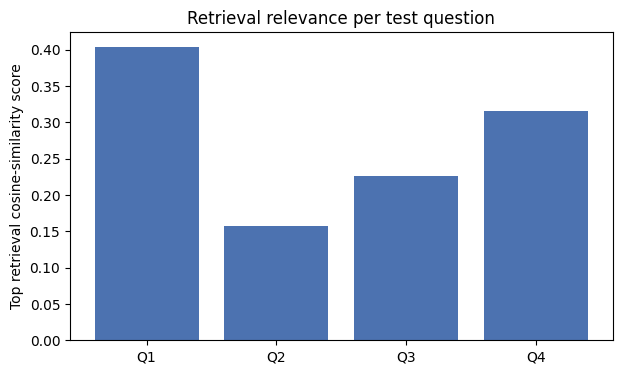

In [7]:
import matplotlib.pyplot as plt

memory2 = ConversationMemory()
scores_per_q = []
for q in test_questions:
    retrieved = store.retrieve(q, k=3)
    top_score = retrieved[0][1] if retrieved else 0
    scores_per_q.append(top_score)

plt.figure(figsize=(7,4))
plt.bar(range(len(test_questions)), scores_per_q, color="#4C72B0")
plt.xticks(range(len(test_questions)), [f"Q{i+1}" for i in range(len(test_questions))])
plt.ylabel("Top retrieval cosine-similarity score")
plt.title("Retrieval relevance per test question")
plt.show()

## 7. Final Summary / Insights

- The TF-IDF + cosine-similarity vector store retrieves clearly relevant chunks for
  direct questions (e.g. dataset names, deadlines) with strong similarity scores.
- **Context memory** lets the chatbot resolve follow-up questions like *"What about
  the deadline?"* correctly, by carrying the previous question's topic forward.
- The same `ask()` function powers both this notebook and the deployed
  **Streamlit app** (`streamlit_app.py`) — the RAG logic is fully decoupled from the UI.
- Swapping the TF-IDF vector store for a neural-embedding store (e.g.
  sentence-transformers + FAISS) would improve semantic matching for paraphrased
  questions, without changing the rest of the architecture.
- Set `ANTHROPIC_API_KEY` to replace DEMO MODE extractive answers with real,
  fluent, grounded LLM-generated responses.